In [16]:
import sys
import pandas as pd
import numpy as np
from datetime import datetime
from geopy.geocoders import Nominatim
import pickle
import re

In [17]:
import certifi
import ssl
import geopy.geocoders
ctx = ssl.create_default_context(cafile=certifi.where())
geopy.geocoders.options.default_ssl_context = ctx

In [18]:
sys.path.append("../../code")
sys.path.append("../../analysis")
import loaders.cityprotect as cp

In [19]:
nom = Nominatim(user_agent="policedata", scheme='http')

In [20]:
previous_df = pd.read_pickle("../../data/clean_data/SCCSheriff_2017_2022_inferredCity.pkl")

In [21]:
dept = "Santa Clara County Office of the Sheriff"
df = cp.cityprotect("../../data/raw_data/{}".format(dept.replace(" ", "_")),
                                 start_date = previous_df["date"].max(),
                                  end_date = datetime.now() )

Starting: 2022-12-31 23:58:48
Ending:   2024-06-12 18:23:56.262103
Loading from 27 files.
Data file ../../data/raw_data/Santa_Clara_County_Office_of_the_Sheriff/Jan_Mar_2017_Santa_Clara_County_Office_of_the_Sheriff_report.csv is empty.
Data file ../../data/raw_data/Santa_Clara_County_Office_of_the_Sheriff/Apr_Jun_2017_Santa_Clara_County_Office_of_the_Sheriff_report.csv is empty.


In [22]:
len(df)

32065

In [23]:
print(df.head())

              ccn                date          updateDate                city  \
76329  S223650282 2022-12-31 23:58:48 2023-01-01 09:05:07  SANTA CLARA COUNTY   
76330  L223650085 2023-01-01 00:15:09 2023-01-01 09:05:06  SANTA CLARA COUNTY   
76331  L223650088 2023-01-01 00:36:17 2023-01-01 09:05:08  SANTA CLARA COUNTY   
76332  L223650094 2023-01-01 00:43:22 2023-01-01 09:05:06  SANTA CLARA COUNTY   
76333  L223650095 2023-01-01 00:45:05 2023-01-01 09:05:07  SANTA CLARA COUNTY   

      state postalCode          blocksizedAddress            incidentType  \
76329    CA          .    14000 Block LOMA RIO DR    PHONE UR OFFICE, OR:   
76330    CA          .         ALUM ROCK FALLS RD  SERVICE OR AID REQUEST   
76331    CA          .                  BONINO LN  SERVICE OR AID REQUEST   
76332    CA          .                      HWY 9  SERVICE OR AID REQUEST   
76333    CA          .  14300 Block LIDDICOAT CIR  SERVICE OR AID REQUEST   

      parentIncidentType                          

In [24]:
if "inferredCity" not in df.columns:
    df['inferredCity'] = ["unknown"]*len(df)

In [25]:
df.loc[df["inferredCity"].apply(lambda x: type(x) == float)] = "unknown"
df.loc[df["inferredCity"].apply(lambda x: x == 'blank')] = "unknown"
print(df["inferredCity"])

76329    unknown
76330    unknown
76331    unknown
76332    unknown
76333    unknown
          ...   
11614    unknown
11615    unknown
11616    unknown
11617    unknown
11618    unknown
Name: inferredCity, Length: 32065, dtype: object


In [26]:
print(dir(cp))

['EmptyDataError', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'attempt_goog', 'attempt_nom', 'cities_in_scc', 'cityprotect', 'datetime', 'get_city', 'glob', 'infer_cities', 'new_attempt_nom', 'pd', 'protect_read_csv', 're', 'reclassification_dir', 'reclassify_incidents', 'zipcode_lookup']


In [27]:
failures = []

In [28]:
# Some blocksizedAddress fields are NaNs, which is Not Helpful
df.loc[df["blocksizedAddress"].apply(lambda x: type(x) == float), "inferredCity"] = "blank"

# We will iterate over unique addresses, not records.
unique_addresses = df[df["inferredCity"] == "unknown"]["blocksizedAddress"].unique()

fail_count = 0

for idx, addr in enumerate(unique_addresses):
    result = cp.new_attempt_nom(nom, addr) # new attempt nom (29% failure) and 296/1000, attempt nom (164/500, 0.328) and 313/1000
    #if not result:
        #result = attempt_goog(goog, addr)
        #googcount += 1

    if result:  # fix all the records at once
        df.loc[df["blocksizedAddress"] == addr, "inferredCity"] = result[0]
        df.loc[df["blocksizedAddress"] == addr, "postcode"] = result[1]
    else:
        #print("Failed to identify {}".format(addr))
        failures.append(addr.upper())
        fail_count += 1  
        print("failed: ", fail_count, " / ", idx+1)

    #if idx%200 == 0:
        #print("Saving...")
        #df.to_pickle("SCCSheriff.pkl")
print("final count: ", fail_count, "/", 100, "failed")

Couldn't find postcode.
Nom: adding house number
Nom: failed, 1000 ALUM ROCK FALLS RD, SANTA CLARA COUNTY
failed:  1  /  2
Nom: could not locate city or not in Santa Clara County of: BONINO LN, SANTA CLARA COUNTY
failed:  2  /  3
Nom could not find postcode/city of: HWY 9, SANTA CLARA COUNTY
failed:  3  /  4
Couldn't find postcode.
Nom: adding house number
Nom: failed, 1000 POLE LINE RD, SANTA CLARA COUNTY
failed:  4  /  6
Nom: could not locate city or not in Santa Clara County of: 1 OGIER AV, SANTA CLARA COUNTY
failed:  5  /  9
Couldn't find postcode.
Nom: adding house number
Couldn't find postcode.
failed:  6  /  13
Nom: could not locate city or not in Santa Clara County of: 19000 UVAS RD, SANTA CLARA COUNTY
failed:  7  /  14
Nom: could not locate city or not in Santa Clara County of: RUCKER AV, SANTA CLARA COUNTY
failed:  8  /  18
Nom: failed, 10600 W LOYOLA DR, SANTA CLARA COUNTY
failed:  9  /  21
Nom: could not locate city or not in Santa Clara County of: 13700 WALLACE PL, SANTA C

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
failures_blob = ' '.join(failures)
wordcloud = WordCloud(width= 3000, height = 2000, random_state=1, background_color='#3D9140', colormap='Pastel2', collocations=False, stopwords = ["BLOCK"]).generate(failures_blob)

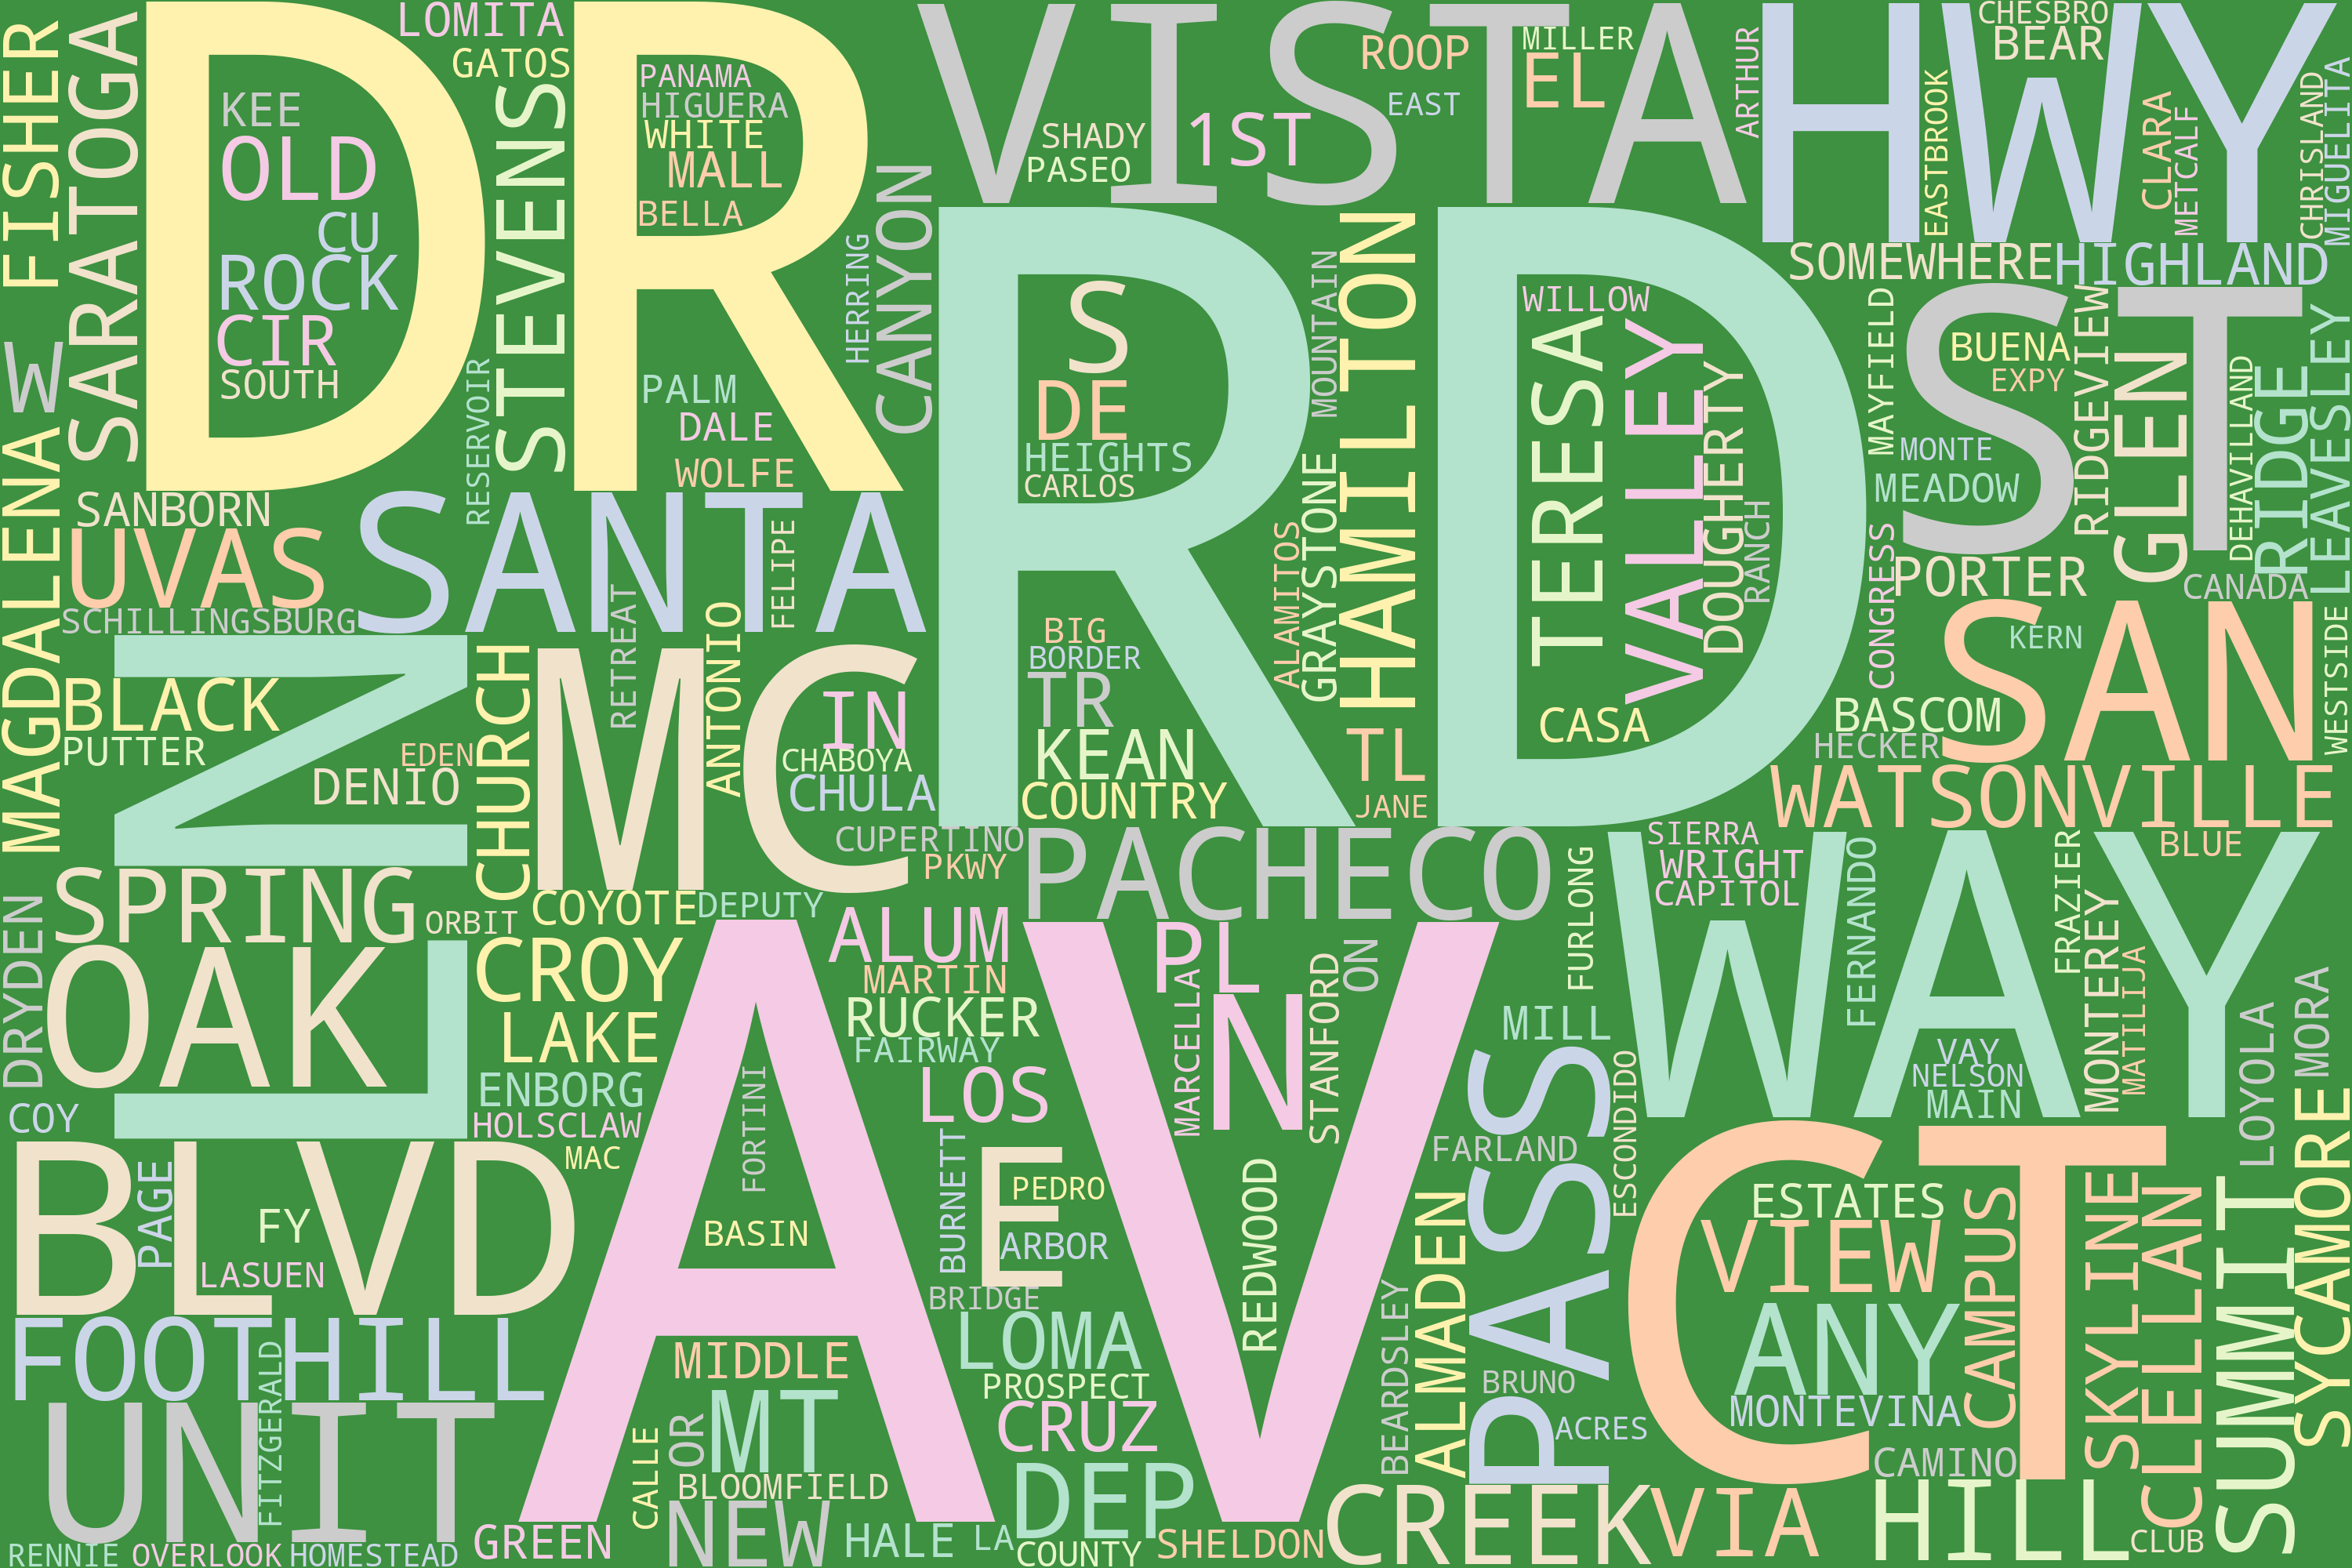

In [36]:
wordcloud.to_image()

In [30]:
from collections import Counter
res = Counter(failures_blob.split())
for i in res.keys():
      print(i, ":", res[i])


ALUM : 11
ROCK : 11
FALLS : 3
RD : 522
BONINO : 2
LN : 137
HWY : 59
9 : 1
POLE : 2
LINE : 3
1 : 221
BLOCK : 1920
OGIER : 2
AV : 489
TRAVIS : 2
CT : 138
19000 : 7
UVAS : 23
RUCKER : 8
10600 : 13
W : 18
LOYOLA : 7
DR : 309
13700 : 7
WALLACE : 1
PL : 18
S : 30
BASCOM : 7
TOBIN : 1
& : 109
28X20 : 1
200 : 59
SAN : 35
BRUNO : 4
STEVENS : 17
CREEK : 23
BLVD : 42
CROY : 15
LAGUNA : 1
FOOTHILL : 25
CANYON : 11
1300 : 5
ARBOR : 5
10900 : 7
N : 32
WOLFE : 6
1900 : 11
QUAIL : 1
MEADOW : 6
BEARDSLEY : 5
HELLYER : 3
20500 : 7
HOMESTEAD : 4
21600 : 4
SCHILLINGSBURG : 5
STELLING : 1
100 : 89
21300 : 3
ALMA : 3
BRIDGE : 4
19300 : 9
OVERLOOK : 4
13600 : 6
19100 : 12
TILSON : 2
EDMUNDSON : 2
ENBORG : 7
15100 : 11
WOODARD : 1
ABEL : 1
ST : 72
400 : 32
WHITE : 6
HOLSCLAW : 5
2300 : 10
LUNDY : 2
TORRE : 2
11200 : 6
9500 : 7
MEG : 1
PICKFORD : 3
MT : 25
HAMILTON : 21
BLOOMFIELD : 5
2200 : 9
15500 : 9
SANBORN : 7
12800 : 8
EL : 11
MONTE : 4
9600 : 3
KERN : 4
19500 : 8
21900 : 5
GILLETTE : 1
26400 : 1
FRANCIS

In [37]:
print(res)

Counter({'BLOCK': 1920, 'RD': 522, 'AV': 489, 'DR': 309, '1': 221, 'CT': 138, 'LN': 137, '&': 109, '100': 89, 'WAY': 85, 'ST': 72, 'MC': 60, 'HWY': 59, '200': 59, '300': 46, 'VISTA': 46, 'BLVD': 42, '500': 38, 'SAN': 35, '600': 35, 'SANTA': 34, 'UNIT': 34, 'PASS': 34, 'E': 34, 'N': 32, '400': 32, 'PACHECO': 31, 'ANY': 31, 'S': 30, 'OAK': 29, '700': 27, 'FOOTHILL': 25, 'MT': 25, 'UVAS': 23, 'CREEK': 23, 'VALLEY': 22, 'SUMMIT': 22, 'HAMILTON': 21, '10200': 21, 'DEP': 20, 'VIEW': 19, '10100': 19, '800': 19, 'GLEN': 19, 'W': 18, 'PL': 18, 'TERESA': 18, '1500': 18, 'STEVENS': 17, 'VIA': 17, 'HILL': 17, '10000': 17, 'SARATOGA': 17, 'NEW': 16, 'SPRINGS': 16, 'CROY': 15, '900': 15, '10500': 15, 'OLD': 15, 'WATSONVILLE': 14, '10600': 13, '10300': 13, '1400': 13, '1000': 13, 'CLELLAN': 13, 'DE': 13, '19100': 12, '10400': 12, 'MAGDALENA': 12, 'IN': 12, '1700': 12, 'ALUM': 11, 'ROCK': 11, 'CANYON': 11, '1900': 11, '15100': 11, 'EL': 11, '1200': 11, 'FISHER': 11, '1100': 11, 'SYCAMORE': 11, 'TR': 1

In [31]:
#df = cp.infer_cities(df, nom)

In [33]:
print(failures)

['ALUM ROCK FALLS RD', 'BONINO LN', 'HWY 9', 'POLE LINE RD', '1 BLOCK BLOCK OGIER AV', 'TRAVIS CT', '19000 BLOCK UVAS RD', 'RUCKER AV', '10600 BLOCK W LOYOLA DR', '13700 BLOCK WALLACE PL', 'S BASCOM AV', 'TOBIN & 28X20', '200 BLOCK SAN BRUNO AV', '200 BLOCK BLOCK STEVENS CREEK BLVD', 'CROY RD', 'LAGUNA AV', 'FOOTHILL AV', 'STEVENS CANYON RD', '1300 BLOCK ARBOR AV', '10900 BLOCK N WOLFE RD', '1900 BLOCK QUAIL MEADOW RD', '19000 BLOCK BEARDSLEY RD', '1 BLOCK BLOCK HELLYER AV', '20500 BLOCK HOMESTEAD RD', '21600 BLOCK SCHILLINGSBURG AV', '1 BLOCK BLOCK S STELLING RD', '100 BLOCK BLOCK STEVENS CANYON RD', '21300 BLOCK HOMESTEAD RD', '200 BLOCK BLOCK HOMESTEAD RD', '100 BLOCK BLOCK ALMA BRIDGE RD', '19300 BLOCK OVERLOOK RD', '13600 BLOCK FOOTHILL AV', '19100 BLOCK TILSON AV', 'W EDMUNDSON AV', '1 BLOCK BLOCK ENBORG CT', '15100 BLOCK WOODARD RD', '1 BLOCK BLOCK S ABEL ST', '400 BLOCK N WHITE RD', 'HOLSCLAW RD', '2300 BLOCK LUNDY PL', '100 BLOCK BLOCK TORRE AV', '11200 BLOCK FOOTHILL AV', '95

In [32]:
orig = "1000 Travis Ct, CA"
place = "TRAVIS CT, SANTA CLARA COUNTY"

def regular_lookup(address):
    location = nom.geocode(address, addressdetails=True)
    if location:
        print("regular lookup: ", location.raw["address"])
        return location
    else:
        print("regular lookup failed")
        return None

def postcode_lookup(address):
    return nom.geocode(address.raw["address"]["postcode"] + ", CA", addressdetails=True).raw["address"]

location = regular_lookup(orig)
#print("postcode lookup: ", postcode_lookup(location))
print("cp lookup: ", cp.new_attempt_nom(nom, orig))

regular lookup:  {'house_number': '1000', 'road': 'Travis Court', 'city': 'Turlock', 'county': 'Stanislaus County', 'state': 'California', 'ISO3166-2-lvl4': 'US-CA', 'postcode': '95380', 'country': 'United States', 'country_code': 'us'}
Couldn't find postcode.
cp lookup:  None
